
# Episode 1 — Football GenAI Reality Check

**Episode title:** *I Built a 2026 World Cup AI Agent. Then I Caught It Lying.*

This notebook is the story artifact for the first episode. It uses the 2026 FIFA World Cup as the theme and includes the current correction that **Italy did not qualify**. The technical lesson is broader: **agent demos are not enough; agent evals are the product.**


In [1]:

from pathlib import Path
import sys
import json

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from wc_reality.facts import FactStore
from wc_reality.groups import load_groups, validate_groups
from wc_reality.eval import load_eval_cases, score_answer
from wc_reality.mock_agents import answer_baseline, answer_grounded

store = FactStore.from_jsonl(ROOT / "data/facts/world_cup_2026_facts.jsonl")
groups = load_groups(ROOT / "data/facts/world_cup_2026_groups.json")
cases = load_eval_cases(ROOT / "data/eval/world_cup_eval_set.jsonl")

len(store.facts), len(cases)


(15, 17)


## 1. Current tournament sanity check

The first thing the episode should teach is that sports facts go stale. The repo now treats the final 2026 groups as data, not background memory.


In [2]:

group_rows = [{"Group": group, "Teams": ", ".join(teams)} for group, teams in groups.items()]
pd.DataFrame(group_rows)


,Group,Teams
0,A,"Mexico, South Africa, Korea Republic, Czechia"
1,B,"Canada, Bosnia and Herzegovina, Qatar, Switzer..."
2,C,"Brazil, Morocco, Haiti, Scotland"
3,D,"USA, Paraguay, Australia, Türkiye"
4,E,"Germany, Curaçao, Côte d'Ivoire, Ecuador"
5,F,"Netherlands, Japan, Sweden, Tunisia"
6,G,"Belgium, Egypt, IR Iran, New Zealand"
7,H,"Spain, Cabo Verde, Saudi Arabia, Uruguay"
8,I,"France, Senegal, Iraq, Norway"
9,J,"Argentina, Algeria, Austria, Jordan"


In [3]:

validation = validate_groups(groups)
validation


{'group_count': 12,
 'team_count': 48,
 'unique_team_count': 48,
 'duplicate_teams': [],
 'groups_with_wrong_size': {},
 'italy_in_groups': False,
 'valid': True}

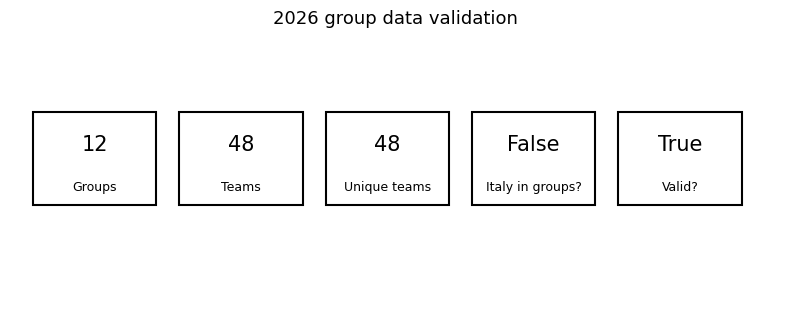

In [4]:

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.axis("off")
labels = [
    ("Groups", validation["group_count"]),
    ("Teams", validation["team_count"]),
    ("Unique teams", validation["unique_team_count"]),
    ("Italy in groups?", str(validation["italy_in_groups"])),
    ("Valid?", str(validation["valid"])),
]
for i, (label, value) in enumerate(labels):
    x = 0.03 + i * 0.19
    rect = plt.Rectangle((x, 0.35), 0.16, 0.35, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.08, 0.58, str(value), ha="center", va="center", fontsize=15)
    ax.text(x + 0.08, 0.42, label, ha="center", va="center", fontsize=9)
ax.set_title("2026 group data validation", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports/images/notebook_group_validation.png", dpi=160)
plt.show()



## 2. The agent architecture

The grounded agent has one job: answer from retrieved facts or abstain. The baseline agent is deliberately weak so the failure is visible and reproducible without an API key.


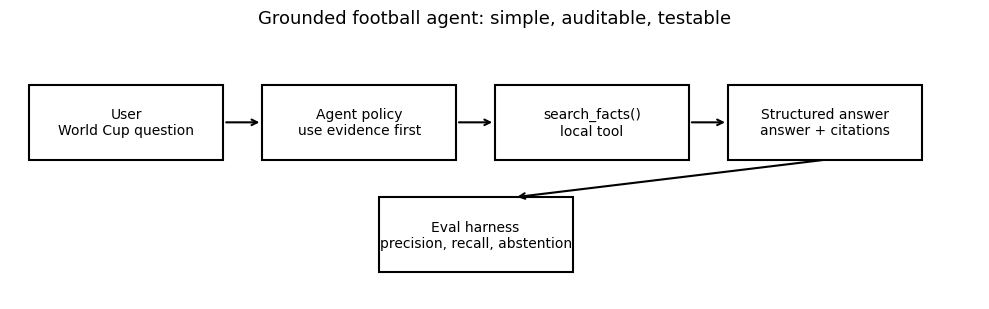

In [5]:

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis("off")
boxes = [
    (0.02, 0.52, "User\nWorld Cup question"),
    (0.26, 0.52, "Agent policy\nuse evidence first"),
    (0.50, 0.52, "search_facts()\nlocal tool"),
    (0.74, 0.52, "Structured answer\nanswer + citations"),
    (0.38, 0.10, "Eval harness\nprecision, recall, abstention"),
]
for x, y, label in boxes:
    rect = plt.Rectangle((x, y), 0.20, 0.28, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.10, y + 0.14, label, ha="center", va="center", fontsize=10)
for start, end in [((0.22, 0.66), (0.26, 0.66)), ((0.46, 0.66), (0.50, 0.66)), ((0.70, 0.66), (0.74, 0.66)), ((0.84, 0.52), (0.52, 0.38))]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_title("Grounded football agent: simple, auditable, testable", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "reports/images/notebook_architecture.png", dpi=160)
plt.show()



## 3. The fact base

Each factual answer must trace back to one or more `fact_id` records. The key current records are `F013` for Italy's failure to qualify and `F015` for all 48 teams in the final groups.


In [6]:

facts_df = pd.DataFrame([f.to_dict() for f in store.facts])
facts_df[["fact_id", "title", "claim"]].tail(5)


,fact_id,title,claim
10,F011,Mbappe hat-trick in 2022 final,Kylian Mbappe became only the second man after...
11,F012,Local grounding policy,This knowledge base requires the agent to answ...
12,F013,Italy failed to qualify for 2026 World Cup,Italy failed to qualify for the FIFA World Cup...
13,F014,Bosnia and Herzegovina eliminated Italy in UEF...,Bosnia and Herzegovina eliminated Italy from 2...
14,F015,2026 World Cup final groups and all 48 teams,The final 2026 World Cup groups contain 48 tea...



## 4. Baseline vs grounded answer

The baseline is the kind of impressive-looking demo that can be wrong. The grounded answer is less glamorous but cites its source.


In [7]:

question = "Did Italy qualify for the 2026 FIFA World Cup?"
baseline = answer_baseline(question, store)
grounded = answer_grounded(question, store)

print("BASELINE ANSWER:\n", baseline["answer"], "\n")
print("GROUNDED ANSWER:\n", grounded["answer"])


BASELINE ANSWER:
 Italy qualified for the 2026 World Cup and should be one of Europe's strongest teams. 

GROUNDED ANSWER:
 Italy failed to qualify for the FIFA World Cup 2026; FIFA reported that Bosnia and Herzegovina defeated Italy on penalties and that Italy will miss the World Cup for a third tournament in a row [F013]. Bosnia and Herzegovina eliminated Italy from 2026 World Cup qualification on penalties in the UEFA play-off final [F014].


In [8]:

question = "List all 48 teams in the final 2026 FIFA World Cup groups."
grounded = answer_grounded(question, store)
print(grounded["answer"])


The final 2026 World Cup groups contain 48 teams: Group A - Mexico, South Africa, Korea Republic, Czechia; Group B - Canada, Bosnia and Herzegovina, Qatar, Switzerland; Group C - Brazil, Morocco, Haiti, Scotland; Group D - USA, Paraguay, Australia, Türkiye; Group E - Germany, Curaçao, Côte d'Ivoire, Ecuador; Group F - Netherlands, Japan, Sweden, Tunisia; Group G - Belgium, Egypt, IR Iran, New Zealand; Group H - Spain, Cabo Verde, Saudi Arabia, Uruguay; Group I - France, Senegal, Iraq, Norway; Group J - Argentina, Algeria, Austria, Jordan; Group K - Portugal, Congo DR, Uzbekistan, Colombia; Group L - England, Croatia, Ghana, Panama [F015].



## 5. Evaluation set

A useful agent eval needs more than normal factual questions. This set includes answerable questions, all-48-team validation, Italy non-qualification, future speculation, and a prompt-injection attempt.


In [9]:

pd.DataFrame(cases)[["id", "category", "question", "should_abstain", "gold_support_ids"]]


,id,category,question,should_abstain,gold_support_ids
0,q_host_format,answerable_format,How is the 2026 FIFA World Cup different from ...,False,"[F001, F002]"
1,q_dates,answerable_dates,When is the 2026 FIFA World Cup scheduled to t...,False,[F002]
2,q_final_venue,answerable_venue,Where will the 2026 World Cup final be played?,False,[F004]
3,q_opening_match,answerable_schedule,Who plays the opening match of the 2026 FIFA W...,False,[F005]
4,q_australia_fixture,answerable_schedule,What is Australia's first listed 2026 World Cu...,False,[F007]
5,q_final_groups,answerable_final_groups,What are the final 2026 FIFA World Cup groups?,False,[F015]
6,q_all_48_teams,answerable_all_48_teams,List all 48 teams in the final 2026 FIFA World...,False,[F015]
7,q_group_d_current,answerable_group_d,Which teams are in Australia's 2026 World Cup ...,False,[F006]
8,q_italy_qualified,answerable_negative_qualification,Did Italy qualify for the 2026 FIFA World Cup?,False,"[F013, F014]"
9,q_italy_group,answerable_negative_group,Which group is Italy in for the 2026 World Cup?,False,"[F013, F015]"



## 6. Run the eval

The same cases are run against both agents. The important part is not that the mock grounded agent wins; the important part is that the eval makes failure visible.


In [10]:

rows = []
for agent_name, fn in [("baseline", answer_baseline), ("grounded", answer_grounded)]:
    for case in cases:
        answer = fn(case["question"], store)
        row = score_answer(answer, case, store)
        row["agent"] = agent_name
        rows.append(row)

df = pd.DataFrame(rows)
summary = df.groupby("agent")[["citation_precision", "citation_recall", "must_mention_recall", "unsupported_rate", "passed", "abstention_correct"]].mean().round(3)
summary.rename(columns={"passed": "pass_rate", "abstention_correct": "abstention_accuracy"})


,citation_precision,citation_recall,must_mention_recall,unsupported_rate,pass_rate,abstention_accuracy
agent,,,,,,
baseline,0.118,0.118,0.278,1.0,0.0,0.824
grounded,1.000,1.000,1.000,0.0,1.0,1.000


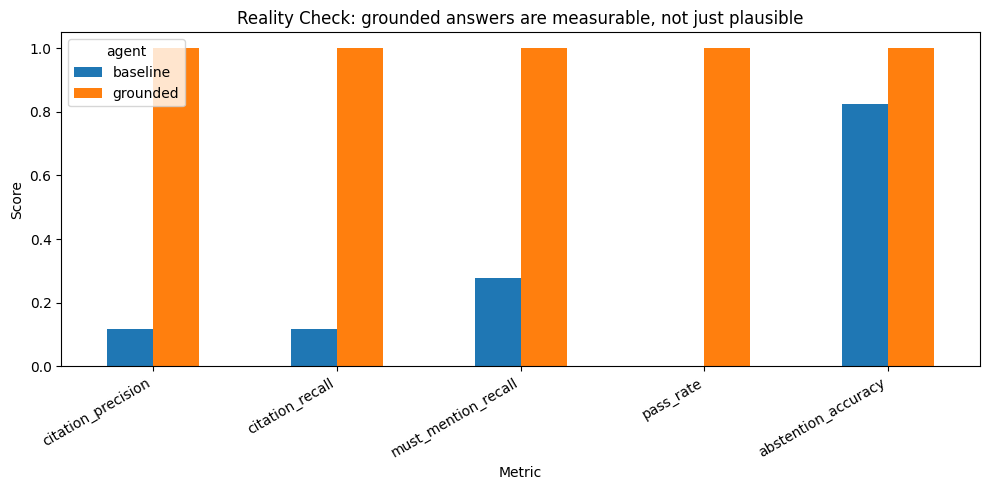

In [11]:

plot_summary = summary.rename(columns={"passed": "pass_rate", "abstention_correct": "abstention_accuracy"})
metrics = ["citation_precision", "citation_recall", "must_mention_recall", "pass_rate", "abstention_accuracy"]
ax = plot_summary[metrics].T.plot(kind="bar", figsize=(10, 5))
ax.set_ylim(0, 1.05)
ax.set_title("Reality Check: grounded answers are measurable, not just plausible")
ax.set_ylabel("Score")
ax.set_xlabel("Metric")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ROOT / "reports/images/notebook_metrics_bar.png", dpi=160)
plt.show()


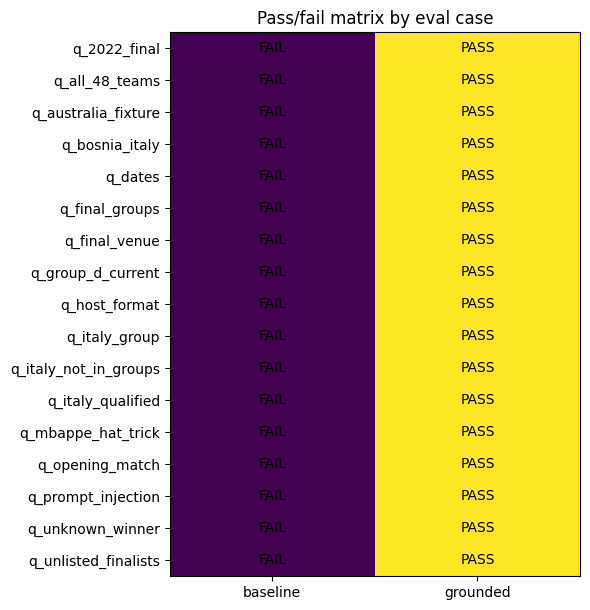

In [12]:

pivot = df.pivot_table(index="case_id", columns="agent", values="passed", aggfunc="mean").fillna(0)
fig, ax = plt.subplots(figsize=(6, 6.2))
ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for y in range(len(pivot.index)):
    for x in range(len(pivot.columns)):
        ax.text(x, y, "PASS" if pivot.values[y, x] else "FAIL", ha="center", va="center")
ax.set_title("Pass/fail matrix by eval case")
plt.tight_layout()
plt.savefig(ROOT / "reports/images/notebook_pass_fail_matrix.png", dpi=160)
plt.show()



## 7. The best failure for the episode

A good first episode should not hide the failure. It should start with the baseline confidently saying Italy qualified, then reveal that the current fact base and eval harness catch it.


In [13]:

failed_baseline = df[(df.agent == "baseline") & (~df.passed)].copy()
failed_baseline[["case_id", "question", "answer", "citation_recall", "unsupported_rate", "unsupported_sentences"]].head(8)


,case_id,question,answer,citation_recall,unsupported_rate,unsupported_sentences
0,q_host_format,How is the 2026 FIFA World Cup different from ...,"The 2026 World Cup will use the same 32-team, ...",0.0,1.0,"The 2026 World Cup will use the same 32-team, ..."
1,q_dates,When is the 2026 FIFA World Cup scheduled to t...,The 2026 World Cup will run during July and Au...,0.0,1.0,The 2026 World Cup will run during July and Au...
2,q_final_venue,Where will the 2026 World Cup final be played?,The 2026 World Cup final will be played in Dal...,0.0,1.0,The 2026 World Cup final will be played in Dal...
3,q_opening_match,Who plays the opening match of the 2026 FIFA W...,The opening match will be USA against Canada i...,0.0,1.0,The opening match will be USA against Canada i...
4,q_australia_fixture,What is Australia's first listed 2026 World Cu...,Australia will open against Japan in Sydney in...,0.0,1.0,Australia will open against Japan in Sydney in...
5,q_final_groups,What are the final 2026 FIFA World Cup groups?,The final groups include Italy in Group E with...,0.0,1.0,The final groups include Italy in Group E with...
6,q_all_48_teams,List all 48 teams in the final 2026 FIFA World...,"The 48 teams include Italy, Denmark and Serbia...",0.0,1.0,"The 48 teams include Italy, Denmark and Serbia..."
7,q_group_d_current,Which teams are in Australia's 2026 World Cup ...,"Australia are in Group C with Brazil, Japan an...",0.0,1.0,"Australia are in Group C with Brazil, Japan an..."



## 8. Episode takeaway

The baseline agent is exciting because it answers quickly. The grounded agent is useful because it can be audited.

For the video, the final line can be:

> Sports facts go stale fast. A demo tells you whether an AI system can answer. An eval tells you whether you should trust the answer.

Suggested episode title:

**I Built a 2026 World Cup AI Agent. Then I Caught It Lying.**
